Stage 1: Project title and objective

Title: Banking Transaction Fraud Detection and Risk Analysis Using Python

Objective:
To analyze behavioral, transactional, and risk-related patterns associated with fraudulent banking transactions and develop a machine-learning classification model capable of identifying potentially fraudulent transactions.

Stage 2: Import Libraries & Load the Dataset

In [6]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [7]:
df = pd.read_csv("banking_transactions.csv")
# Display the first five rows
df.head(5)

,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,payment_channel,authentication_type,card_present_flag,international_transaction_flag,suspicious_ip_flag,fraud_flag
0,1000001,17829.01,4,12.0,13,0.37,2354,22,25,112760.07,63,3189,92,71.8,POS Terminal,OTP,1,1,1,False
1,1000002,16401.83,1,34.3,17,0.26,3181,17,15,118899.52,83,839,63,11.8,Web Banking,Biometric,0,0,1,False
2,1000003,9678.29,8,67.8,39,0.15,1390,3,2,408168.98,9,3938,80,35.7,ATM,OTP,1,0,1,False
3,1000004,19013.38,5,17.8,42,0.55,3716,16,6,80771.69,78,11111,11,74.8,Mobile App,OTP,1,1,0,False
4,1000005,13834.95,3,88.9,63,0.24,4694,16,10,382265.32,17,3171,87,0.0,Mobile App,OTP,1,0,0,False


In [8]:
# Check the dimensions
df.shape

(10000, 20)

In [9]:
# Display the column names
df.columns

Index(['transaction_id', 'transaction_amount', 'login_attempts',
       'device_risk_score', 'transfer_frequency', 'anomaly_score',
       'account_age_days', 'transaction_time_hour',
       'failed_transactions_last_30d', 'avg_monthly_balance',
       'daily_transaction_count', 'geo_distance_km',
       'session_duration_minutes', 'transaction_velocity_score',
       'payment_channel', 'authentication_type', 'card_present_flag',
       'international_transaction_flag', 'suspicious_ip_flag', 'fraud_flag'],
      dtype='object')

In [10]:
# Check the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   transaction_id                  10000 non-null  int64  
 1   transaction_amount              10000 non-null  float64
 2   login_attempts                  10000 non-null  int64  
 3   device_risk_score               10000 non-null  float64
 4   transfer_frequency              10000 non-null  int64  
 5   anomaly_score                   10000 non-null  float64
 6   account_age_days                10000 non-null  int64  
 7   transaction_time_hour           10000 non-null  int64  
 8   failed_transactions_last_30d    10000 non-null  int64  
 9   avg_monthly_balance             10000 non-null  float64
 10  daily_transaction_count         10000 non-null  int64  
 11  geo_distance_km                 10000 non-null  int64  
 12  session_duration_minutes        1

In [11]:
# Generate descriptive statistics
df.describe()

,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,card_present_flag,international_transaction_flag,suspicious_ip_flag
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.005000e+06,12412.754004,6.438900,50.257190,39.648400,0.348916,2510.240900,11.553600,12.437800,249367.527976,60.614300,7604.567500,60.479300,50.122240,0.492800,0.498400,0.500500
std,2.886896e+03,7200.700863,3.453558,29.414463,23.419868,0.236890,1436.335019,6.962254,7.532875,144580.006647,34.821533,4330.728784,34.833419,29.271512,0.499973,0.500022,0.500025
min,1.000001e+06,6.270000,1.000000,0.000000,0.000000,0.010000,6.000000,0.000000,0.000000,104.160000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.002501e+06,6174.025000,3.000000,25.100000,19.000000,0.170000,1271.750000,6.000000,6.000000,122291.355000,30.750000,3896.000000,30.000000,24.800000,0.000000,0.000000,0.000000
50%,1.005000e+06,12322.965000,6.000000,50.200000,40.000000,0.310000,2511.000000,11.000000,13.000000,249799.800000,60.000000,7645.000000,61.000000,50.150000,0.000000,0.000000,1.000000
75%,1.007500e+06,18619.650000,9.000000,75.500000,60.000000,0.480000,3746.250000,18.000000,19.000000,373146.842500,91.000000,11376.250000,91.000000,75.400000,1.000000,1.000000,1.000000
max,1.010000e+06,24997.520000,12.000000,100.000000,80.000000,0.990000,5000.000000,23.000000,25.000000,499968.250000,120.000000,14997.000000,120.000000,100.000000,1.000000,1.000000,1.000000


Stage 3: Data Understanding & Quality Assessment

In [12]:
# Check missing values
df.isnull().sum()

transaction_id                    0
transaction_amount                0
login_attempts                    0
device_risk_score                 0
transfer_frequency                0
anomaly_score                     0
account_age_days                  0
transaction_time_hour             0
failed_transactions_last_30d      0
avg_monthly_balance               0
daily_transaction_count           0
geo_distance_km                   0
session_duration_minutes          0
transaction_velocity_score        0
payment_channel                   0
authentication_type               0
card_present_flag                 0
international_transaction_flag    0
suspicious_ip_flag                0
fraud_flag                        0
dtype: int64

In [13]:
# Check Duplicate Records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [14]:
# Check Unique Values in Categorical Variables
categorical_cols = df.select_dtypes(include=['object','bool']).columns

for col in categorical_cols:
    print(df[col].value_counts())

payment_channel
Mobile App      4804
Web Banking     3247
POS Terminal    1172
ATM              777
Name: count, dtype: int64
authentication_type
OTP                          4214
Two-Factor Authentication    2384
Password Only                1817
Biometric                    1585
Name: count, dtype: int64
fraud_flag
False    8749
True     1251
Name: count, dtype: int64


In [15]:
# Check Class Distribution
round(df['fraud_flag'].value_counts(normalize=True)*100,2)

fraud_flag
False    87.49
True     12.51
Name: proportion, dtype: float64

In [22]:
print("Fraud Amount : ", df[df['fraud_flag']==1]['transaction_amount'].sum())

Fraud Amount :  15657404.21


In [33]:
# Check Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_id,10000.0,1.005000e+06,2886.895680,1000001.00,1002500.750,1005000.500,1.007500e+06,1010000.00
transaction_amount,10000.0,1.241275e+04,7200.700863,6.27,6174.025,12322.965,1.861965e+04,24997.52
login_attempts,10000.0,6.438900e+00,3.453558,1.00,3.000,6.000,9.000000e+00,12.00
device_risk_score,10000.0,5.025719e+01,29.414463,0.00,25.100,50.200,7.550000e+01,100.00
transfer_frequency,10000.0,3.964840e+01,23.419868,0.00,19.000,40.000,6.000000e+01,80.00
anomaly_score,10000.0,3.489160e-01,0.236890,0.01,0.170,0.310,4.800000e-01,0.99
account_age_days,10000.0,2.510241e+03,1436.335019,6.00,1271.750,2511.000,3.746250e+03,5000.00
transaction_time_hour,10000.0,1.155360e+01,6.962254,0.00,6.000,11.000,1.800000e+01,23.00
failed_transactions_last_30d,10000.0,1.243780e+01,7.532875,0.00,6.000,13.000,1.900000e+01,25.00
avg_monthly_balance,10000.0,2.493675e+05,144580.006647,104.16,122291.355,249799.800,3.731468e+05,499968.25


In [34]:
# Check Transaction Amount Distribution
df['transaction_amount'].describe()

count    10000.000000
mean     12412.754004
std       7200.700863
min          6.270000
25%       6174.025000
50%      12322.965000
75%      18619.650000
max      24997.520000
Name: transaction_amount, dtype: float64

In [35]:
# Check Correlation Between Numeric Features
numeric_df = df.select_dtypes(include=['number'])

corr = numeric_df.corr()

corr

,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,card_present_flag,international_transaction_flag,suspicious_ip_flag
transaction_id,1.000000,-0.007378,-0.003757,-0.008601,0.013535,-0.010033,-0.008504,-0.004304,-0.017222,0.007879,0.009662,0.012482,-0.004925,0.000568,0.006240,-0.025432,-0.003513
transaction_amount,-0.007378,1.000000,-0.001595,0.007948,-0.011134,-0.000026,-0.010839,-0.018041,-0.004773,-0.015688,-0.004291,0.000966,-0.007479,0.013551,-0.007195,-0.003678,-0.003655
login_attempts,-0.003757,-0.001595,1.000000,-0.017897,-0.019065,0.003082,0.002428,-0.003992,0.011589,0.009248,0.008822,0.005758,-0.010540,0.000479,0.000295,0.002173,-0.005484
device_risk_score,-0.008601,0.007948,-0.017897,1.000000,0.007358,0.005536,-0.004030,-0.013126,0.002800,0.008122,0.005609,0.000736,0.001284,-0.001588,0.000277,-0.012090,-0.002246
transfer_frequency,0.013535,-0.011134,-0.019065,0.007358,1.000000,-0.003774,0.009342,0.015955,-0.001191,0.010123,-0.006764,0.002743,-0.007889,0.000010,0.007881,-0.019170,0.009358
anomaly_score,-0.010033,-0.000026,0.003082,0.005536,-0.003774,1.000000,-0.009496,-0.005327,0.016186,-0.011233,-0.002879,-0.009896,-0.001880,0.007245,-0.002962,-0.000935,0.006506
account_age_days,-0.008504,-0.010839,0.002428,-0.004030,0.009342,-0.009496,1.000000,0.000171,0.007471,-0.002155,0.024294,-0.005581,0.010508,-0.013378,-0.001928,-0.007975,-0.006336
transaction_time_hour,-0.004304,-0.018041,-0.003992,-0.013126,0.015955,-0.005327,0.000171,1.000000,0.001499,-0.001696,0.001528,-0.001797,-0.012238,0.002820,0.002065,-0.004715,0.024856
failed_transactions_last_30d,-0.017222,-0.004773,0.011589,0.002800,-0.001191,0.016186,0.007471,0.001499,1.000000,-0.003086,0.010797,0.013933,-0.017541,-0.002272,0.008458,-0.005284,-0.006006
avg_monthly_balance,0.007879,-0.015688,0.009248,0.008122,0.010123,-0.011233,-0.002155,-0.001696,-0.003086,1.000000,-0.004637,0.010919,0.012516,0.007282,-0.003110,-0.002889,-0.016152


Stage 4: Exploratory Data Analysis (EDA)

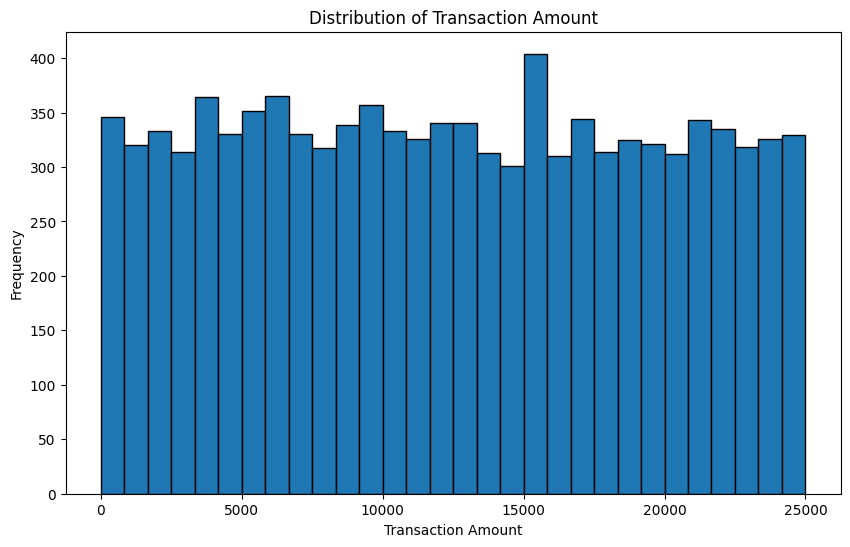

In [37]:
# Distribution of Transaction Amount
plt.figure(figsize=(10,6))

plt.hist(df['transaction_amount'], bins=30, edgecolor='black')

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

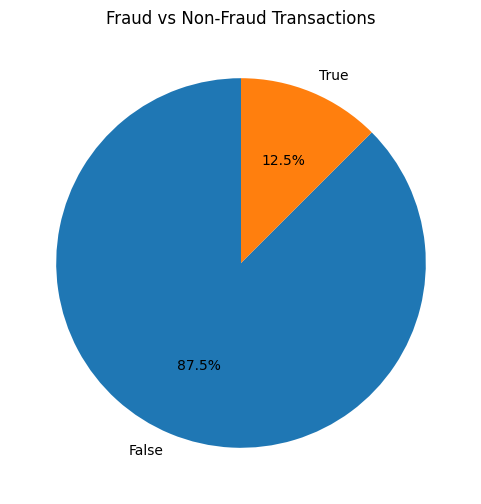

In [39]:
# Fraud vs Non-Fraud Distribution
plt.figure(figsize=(6,6))

df['fraud_flag'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.ylabel("")
plt.title("Fraud vs Non-Fraud Transactions")

plt.show()

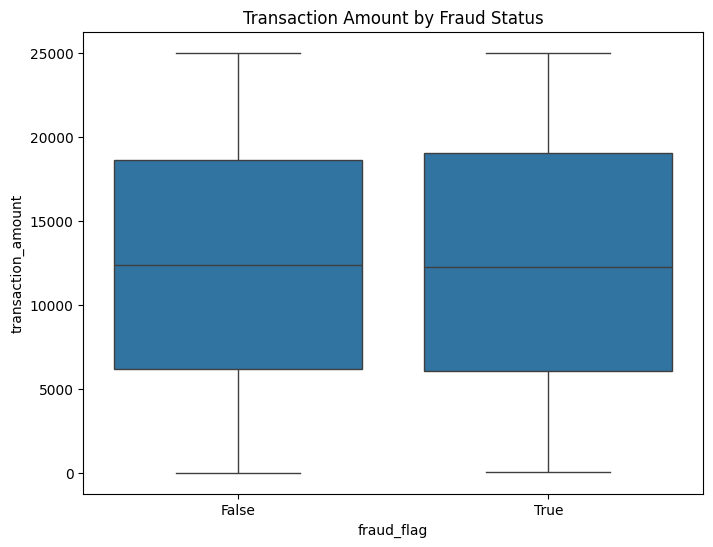

In [40]:
# Transaction Amount by Fraud Status
plt.figure(figsize=(8,6))

sns.boxplot(
    x='fraud_flag',
    y='transaction_amount',
    data=df
)

plt.title("Transaction Amount by Fraud Status")

plt.show()

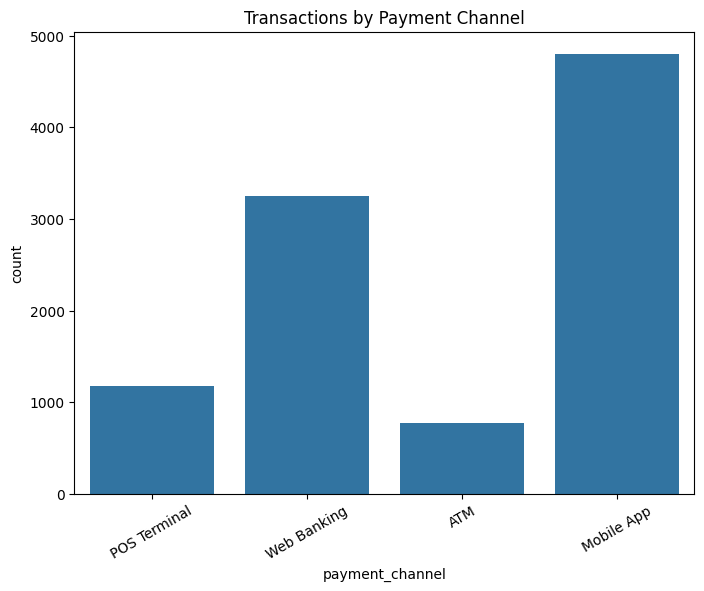

In [41]:
# Payment Channel Distribution
plt.figure(figsize=(8,6))

sns.countplot(
    x='payment_channel',
    data=df
)

plt.title("Transactions by Payment Channel")

plt.xticks(rotation=30)

plt.show()

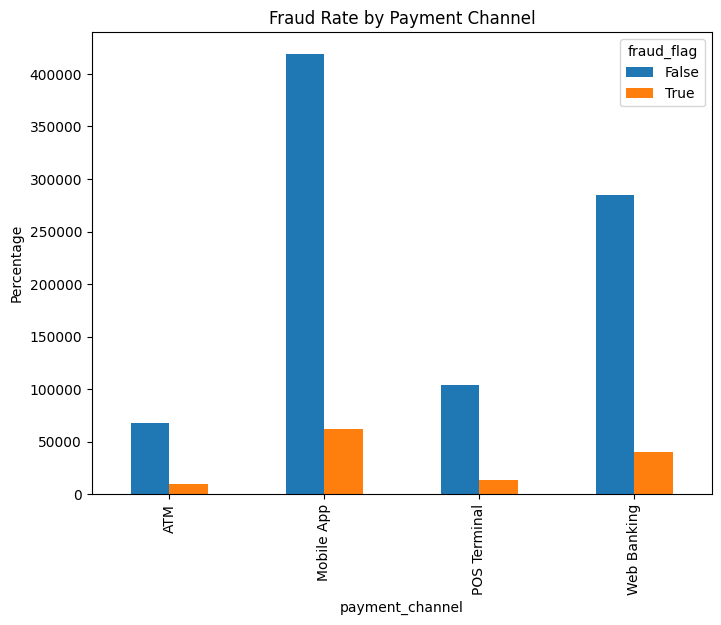

In [46]:
# Fraud Rate by Payment Channel
fraud_channel = pd.crosstab(
    df['payment_channel'],
    df['fraud_flag'],
) * 100

fraud_channel.plot(kind='bar', figsize=(8,6))

plt.ylabel("Percentage")
plt.title("Fraud Rate by Payment Channel")

plt.show()

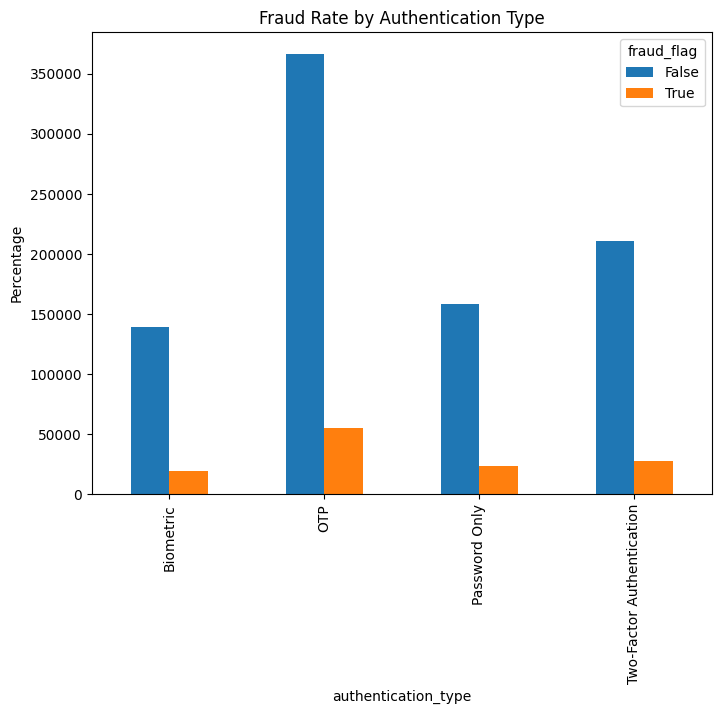

In [48]:
# Authentication Type vs Fraud
fraud_auth = pd.crosstab(
    df['authentication_type'],
    df['fraud_flag'],
)*100

fraud_auth.plot(kind='bar', figsize=(8,6))

plt.ylabel("Percentage")

plt.title("Fraud Rate by Authentication Type")

plt.show()

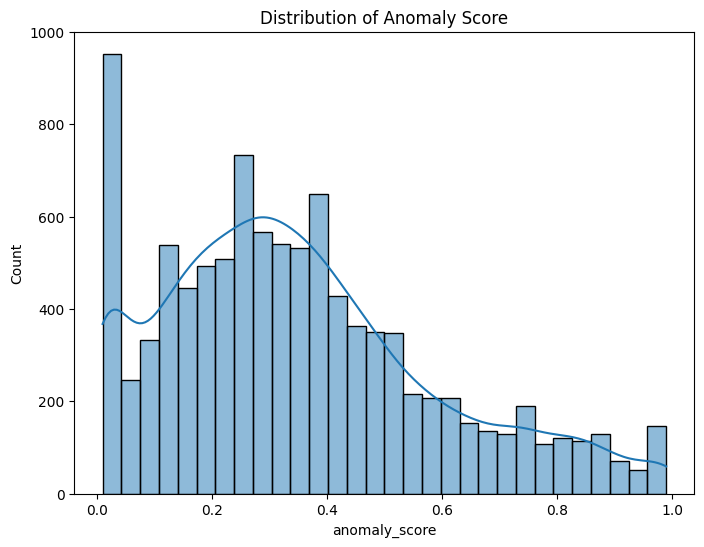

In [49]:
# Anomaly Score Distribution
plt.figure(figsize=(8,6))

sns.histplot(
    df['anomaly_score'],
    bins=30,
    kde=True
)

plt.title("Distribution of Anomaly Score")

plt.show()

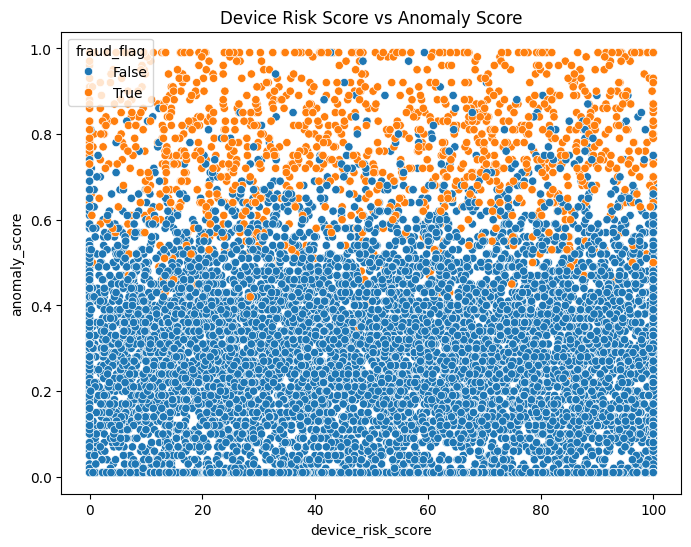

In [50]:
# Device Risk Score vs Anomaly Score
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='device_risk_score',
    y='anomaly_score',
    hue='fraud_flag'
)

plt.title("Device Risk Score vs Anomaly Score")

plt.show()

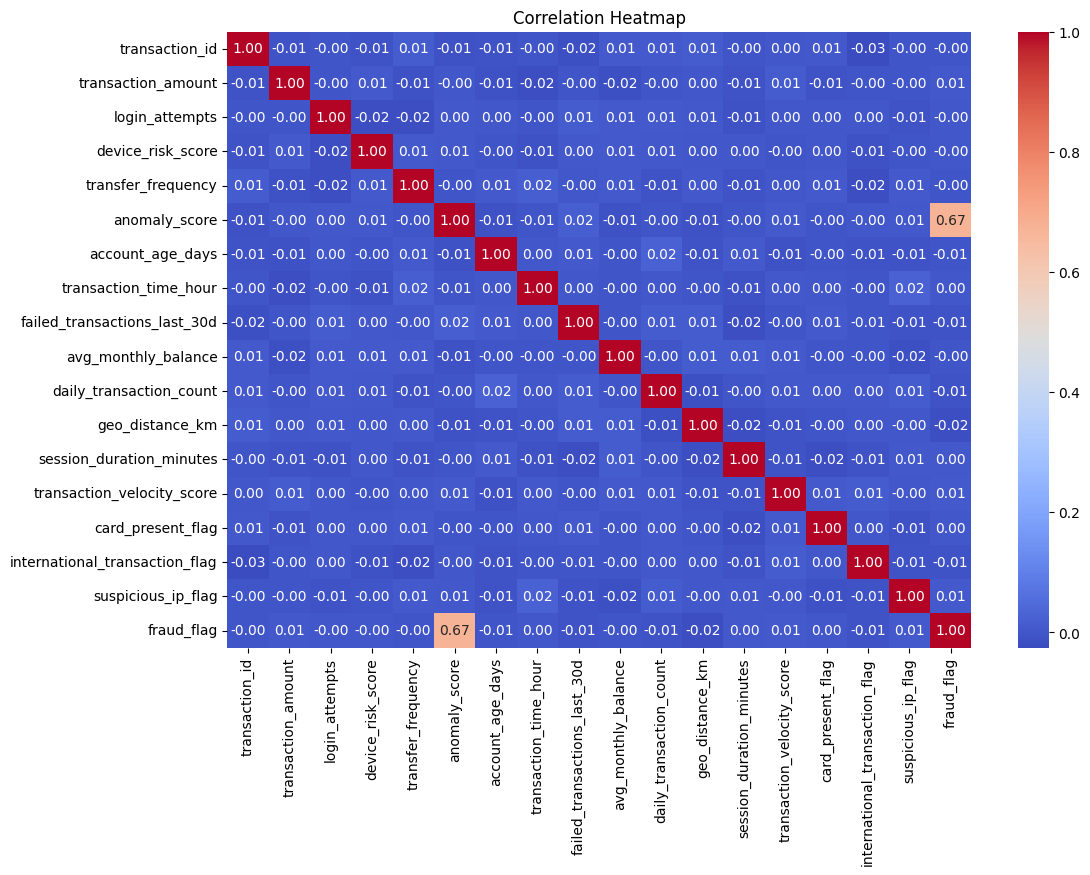

In [51]:
# Correlation Heatmap
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

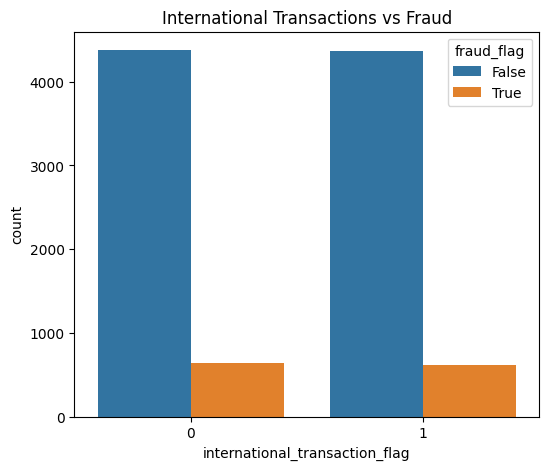

In [52]:
# International Transactions
plt.figure(figsize=(6,5))

sns.countplot(
    x='international_transaction_flag',
    hue='fraud_flag',
    data=df
)

plt.title("International Transactions vs Fraud")

plt.show()

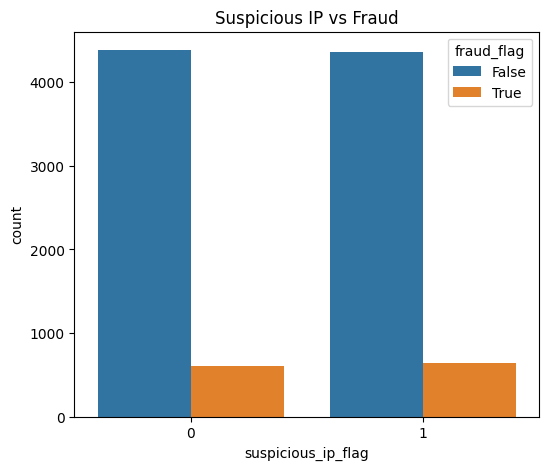

In [53]:
# Suspicious IP vs Fraud
plt.figure(figsize=(6,5))

sns.countplot(
    x='suspicious_ip_flag',
    hue='fraud_flag',
    data=df
)

plt.title("Suspicious IP vs Fraud")

plt.show()

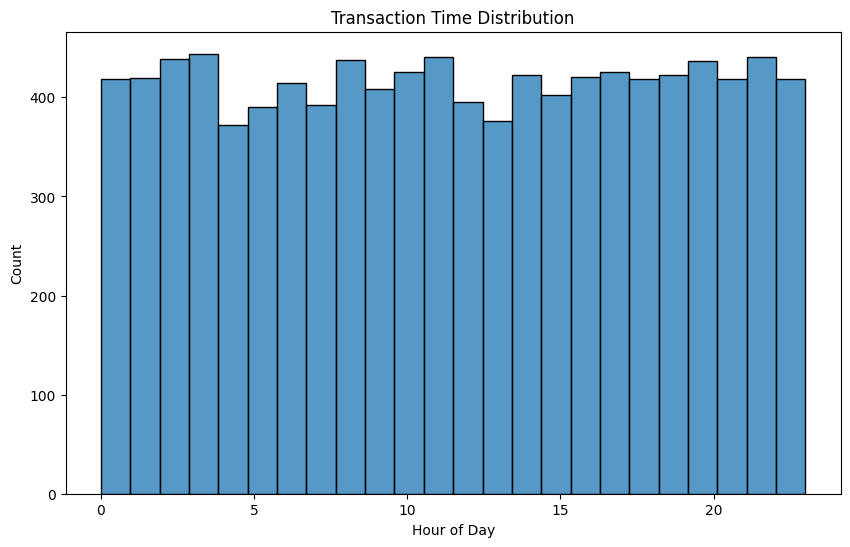

In [54]:
# Transaction Hour Distribution
plt.figure(figsize=(10,6))

sns.histplot(
    df['transaction_time_hour'],
    bins=24
)

plt.title("Transaction Time Distribution")

plt.xlabel("Hour of Day")

plt.show()

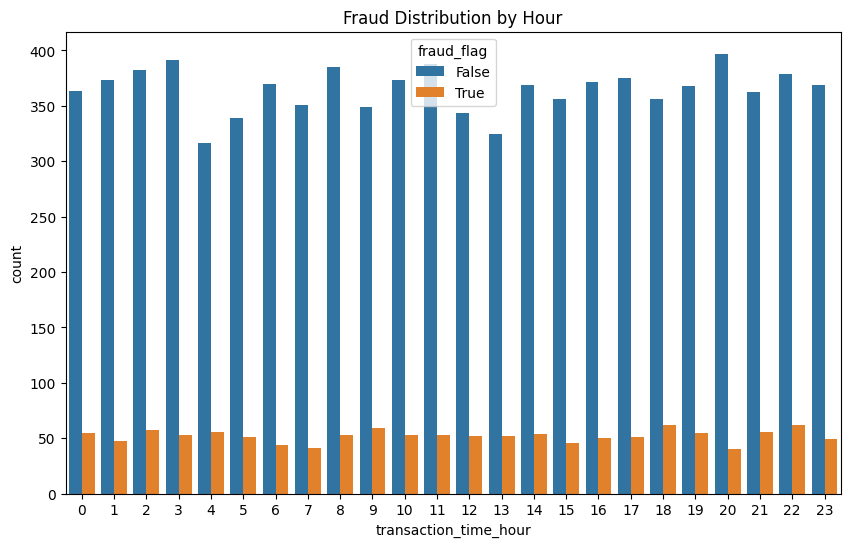

In [55]:
# Fraud by Hour
plt.figure(figsize=(10,6))

sns.countplot(
    x='transaction_time_hour',
    hue='fraud_flag',
    data=df
)

plt.title("Fraud Distribution by Hour")

plt.show()

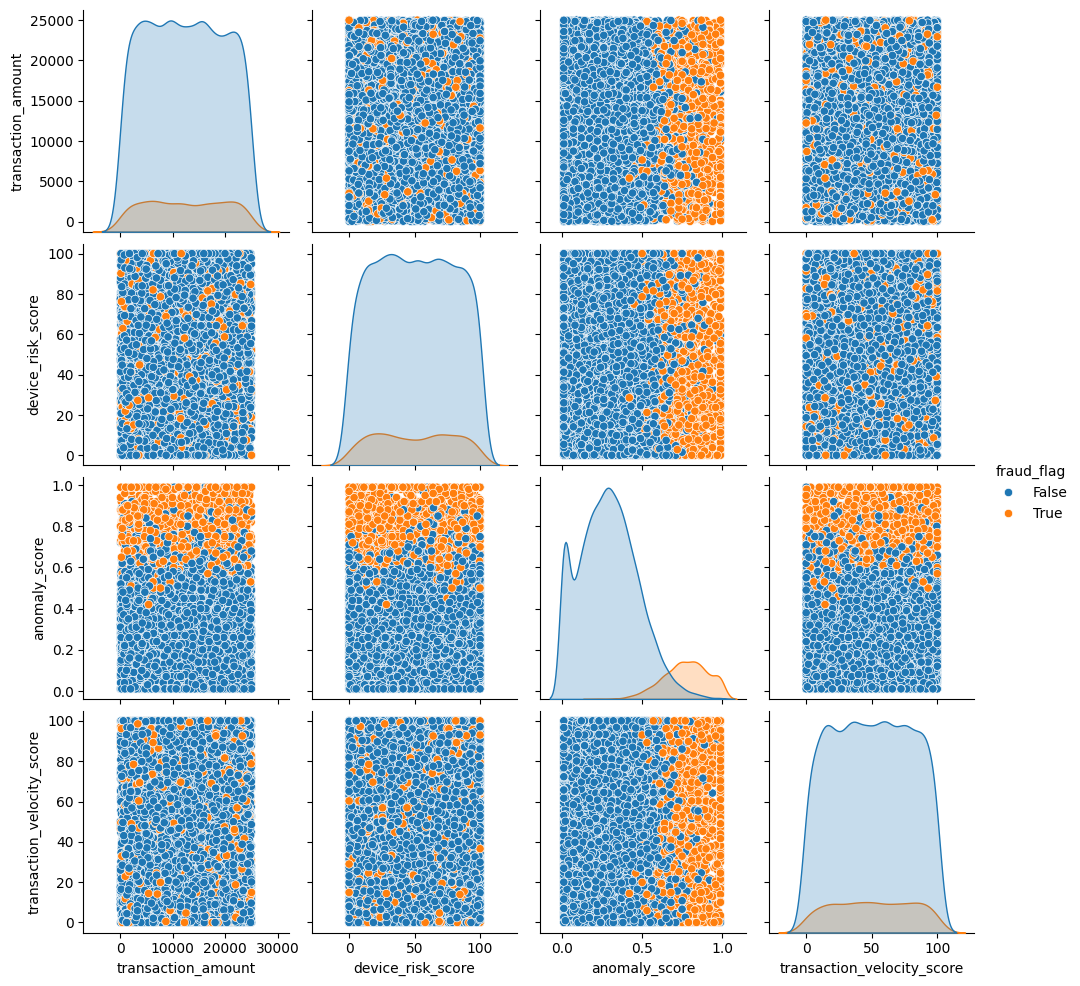

In [56]:
# relationships between several important variables
sns.pairplot(
    df[['transaction_amount',
        'device_risk_score',
        'anomaly_score',
        'transaction_velocity_score',
        'fraud_flag']],
    hue='fraud_flag'
)

Stage 5: Feature Engineering & Data Preprocessing

In [57]:
# Create a Copy of the Dataset
model_df = df.copy()

In [58]:
# Remove Unnecessary Columns
model_df = model_df.drop(columns=['transaction_id'])

In [59]:
# Check Data Types
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   transaction_amount              10000 non-null  float64
 1   login_attempts                  10000 non-null  int64  
 2   device_risk_score               10000 non-null  float64
 3   transfer_frequency              10000 non-null  int64  
 4   anomaly_score                   10000 non-null  float64
 5   account_age_days                10000 non-null  int64  
 6   transaction_time_hour           10000 non-null  int64  
 7   failed_transactions_last_30d    10000 non-null  int64  
 8   avg_monthly_balance             10000 non-null  float64
 9   daily_transaction_count         10000 non-null  int64  
 10  geo_distance_km                 10000 non-null  int64  
 11  session_duration_minutes        10000 non-null  int64  
 12  transaction_velocity_score      1

In [60]:
# Encode Categorical Variables
model_df = pd.get_dummies(
    model_df,
    columns=[
        'payment_channel',
        'authentication_type'
    ],
    drop_first=True
)

In [65]:
model_df.head(5)

,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,...,card_present_flag,international_transaction_flag,suspicious_ip_flag,fraud_flag,payment_channel_Mobile App,payment_channel_POS Terminal,payment_channel_Web Banking,authentication_type_OTP,authentication_type_Password Only,authentication_type_Two-Factor Authentication
0,17829.01,4,12.0,13,0.37,2354,22,25,112760.07,63,...,1,1,1,False,False,True,False,True,False,False
1,16401.83,1,34.3,17,0.26,3181,17,15,118899.52,83,...,0,0,1,False,False,False,True,False,False,False
2,9678.29,8,67.8,39,0.15,1390,3,2,408168.98,9,...,1,0,1,False,False,False,False,True,False,False
3,19013.38,5,17.8,42,0.55,3716,16,6,80771.69,78,...,1,1,0,False,True,False,False,True,False,False
4,13834.95,3,88.9,63,0.24,4694,16,10,382265.32,17,...,1,0,0,False,True,False,False,True,False,False


In [66]:
# Convert Fraud Label into Numbers
model_df['fraud_flag'] = model_df['fraud_flag'].astype(int)

In [67]:
# Define Features (X) and Target (y)
X = model_df.drop('fraud_flag', axis=1)

y = model_df['fraud_flag']

In [69]:
# Check the Shape
print("Features:", X.shape)
print("Target:", y.shape)

Features: (10000, 22)
Target: (10000,)


In [71]:
# Split the Dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [72]:
# Verify the Split
print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (8000, 22)
Testing Data : (2000, 22)


In [74]:
# Prepare scaled data and Confirm scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]

array([[-0.832476  , -0.41553376, -1.06783225,  1.21392043,  0.51176672,
        -1.27366606,  0.35186068, -1.39396851, -0.72334167, -0.07142754,
         0.02500138, -0.22109995,  0.54398407, -0.98881258, -0.99203175,
         1.00853643,  1.04005144, -0.36290742, -0.69527291, -0.85205507,
         2.10852592, -0.56079611],
       [-0.876474  , -1.57280796, -0.85354445, -0.96647735,  0.93500299,
         1.17067474,  1.35856369, -0.72699793,  1.57255961, -0.47290723,
        -1.24907621,  1.09731695,  0.43156216,  1.011314  , -0.99203175,
         1.00853643,  1.04005144, -0.36290742, -0.69527291, -0.85205507,
        -0.47426498,  1.78317927],
       [-0.31240599,  1.03105897,  1.38797397, -0.62445417, -1.30814925,
        -0.88226564,  0.63949011, -1.26057439,  0.72011877,  0.96094882,
         1.20326981, -0.85164716,  1.48424003, -0.98881258, -0.99203175,
         1.00853643, -0.9614909 , -0.36290742, -0.69527291,  1.17363306,
        -0.47426498, -0.56079611],
       [-1.46142705

Data Preprocessing Summary

Removed the transaction identifier as it does not contribute to prediction.
Applied one-hot encoding to categorical features.
Converted the fraud label into a binary numeric format.
Separated features and target variables.
Split the dataset into training and testing sets using stratified sampling.
Standardized numerical features for algorithms that are sensitive to feature scales.

Stage 6: Machine Learning Model Development

Objective
Train and compare multiple classification models to identify the most effective algorithm for fraud detection.

In [77]:
# Model 1: Logistic Regression (Baseline Model)
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [78]:
# Make Predictions
y_pred_log = log_model.predict(X_test_scaled)

In [79]:
# Calculate Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))

Accuracy : 0.9535
Precision: 0.8398268398268398
Recall   : 0.776
F1 Score : 0.8066528066528067


In [80]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1750
           1       0.84      0.78      0.81       250

    accuracy                           0.95      2000
   macro avg       0.90      0.88      0.89      2000
weighted avg       0.95      0.95      0.95      2000



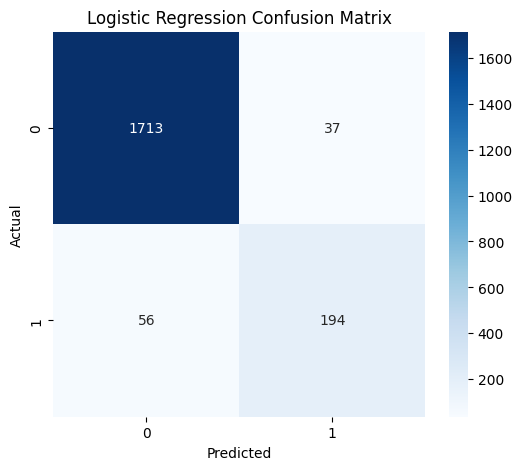

In [81]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [83]:
# Model 2: Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [84]:
# Evaluation using same metrics
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

Accuracy : 0.9445
Precision: 0.7813765182186235
Recall   : 0.772
F1 Score : 0.7766599597585513


In [85]:
# Model 3: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [86]:
# Evaluation using same metrics
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.9525
Precision: 0.8270042194092827
Recall   : 0.784
F1 Score : 0.8049281314168378


In [87]:
# ROC-AUC Score
from sklearn.metrics import roc_auc_score

log_auc = roc_auc_score(
    y_test,
    log_model.predict_proba(X_test_scaled)[:,1]
)

rf_auc = roc_auc_score(
    y_test,
    rf_model.predict_proba(X_test)[:,1]
)

print("Logistic Regression AUC:", round(log_auc,3))
print("Random Forest AUC:", round(rf_auc,3))

Logistic Regression AUC: 0.979
Random Forest AUC: 0.975


In [88]:
# Compare the Models

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9535,0.839827,0.776,0.806653
1,Decision Tree,0.9445,0.781377,0.772,0.776660
2,Random Forest,0.9525,0.827004,0.784,0.804928


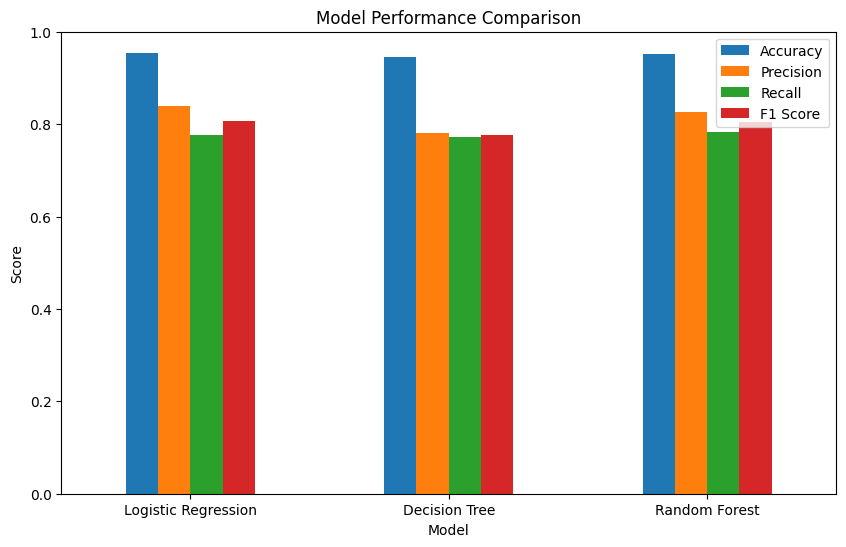

In [89]:
# Visualize Model Performance
results.set_index("Model")[["Accuracy","Precision","Recall","F1 Score"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.ylim(0,1)

plt.xticks(rotation=0)

plt.show()

Machine Learning Summary

Three classification algorithms were developed and evaluated: Logistic Regression, Decision Tree, and Random Forest. Performance was assessed using Accuracy, Precision, Recall, F1-score, ROC-AUC, and Confusion Matrix analysis. Comparing multiple models allowed identification of the algorithm that best balanced fraud detection performance and false positive control for this dataset.

Stage 7 — Model Interpretation & Business Recommendations

In [90]:
# Random Forest
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
4,anomaly_score,0.620751
10,geo_distance_km,0.036245
8,avg_monthly_balance,0.032868
5,account_age_days,0.031835
0,transaction_amount,0.031539
2,device_risk_score,0.030950
12,transaction_velocity_score,0.030206
9,daily_transaction_count,0.029961
11,session_duration_minutes,0.029571
3,transfer_frequency,0.026785


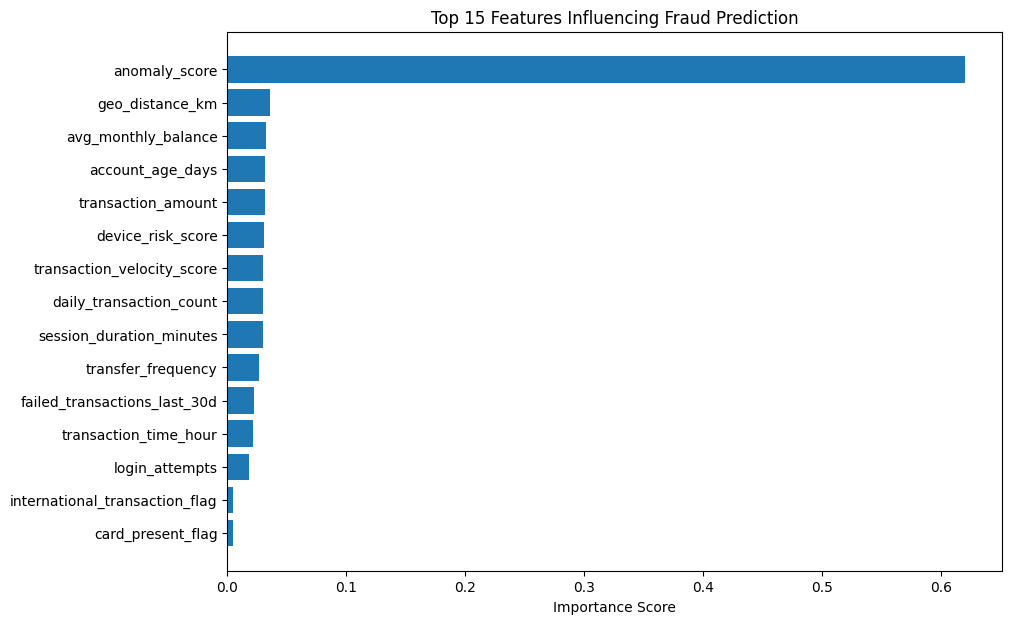

In [91]:
# Plot the Top 15 Features
plt.figure(figsize=(10,7))

plt.barh(
    feature_importance['Feature'][:15][::-1],
    feature_importance['Importance'][:15][::-1]
)

plt.xlabel("Importance Score")
plt.title("Top 15 Features Influencing Fraud Prediction")

plt.show()

The model identified Anomaly Score, Geo_distanace_km, Account_age_delay, Device Risk Score, and Transaction Velocity Score as the strongest predictors of fraudulent transactions. These variables capture unusual customer behavior, suggesting that behavioral indicators are more informative than transaction amount alone.

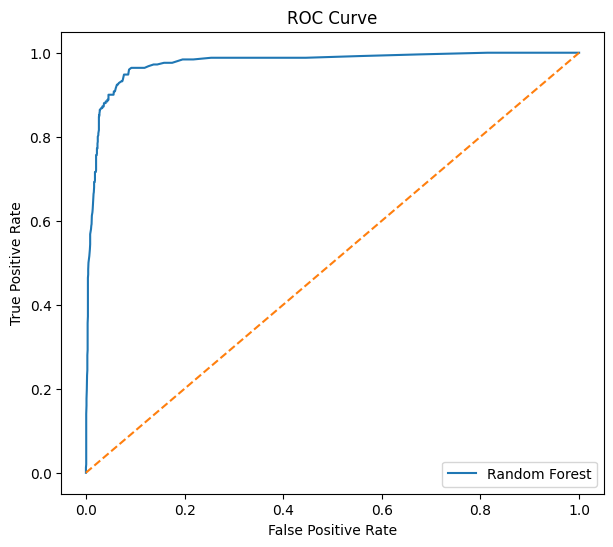

In [92]:
# ROC Curve
from sklearn.metrics import roc_curve

probabilities = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    probabilities
)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label="Random Forest")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()


Interpretation

The ROC curve demonstrates the model's ability to distinguish fraudulent from legitimate transactions across different classification thresholds. A curve closer to the upper-left corner indicates stronger discrimination.

In [93]:
# Which Transactions Were Misclassified?
comparison = X_test.copy()

comparison['Actual'] = y_test.values

comparison['Predicted'] = y_pred_rf

comparison.head()

,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,...,international_transaction_flag,suspicious_ip_flag,payment_channel_Mobile App,payment_channel_POS Terminal,payment_channel_Web Banking,authentication_type_OTP,authentication_type_Password Only,authentication_type_Two-Factor Authentication,Actual,Predicted
8300,11747.77,3,71.4,38,0.17,3272,5,25,284020.78,93,...,1,0,True,False,False,True,False,False,0,0
3372,15496.84,9,82.5,64,0.55,3374,6,25,260491.15,75,...,0,0,False,False,True,False,False,False,0,0
1036,16163.59,1,91.3,4,0.20,2596,6,15,239828.58,11,...,0,1,True,False,False,False,False,True,0,0
214,6981.03,10,84.2,71,0.01,611,17,24,441301.90,18,...,0,0,False,False,True,True,False,False,0,0
4242,2474.17,5,97.3,4,0.01,4702,20,24,370151.51,61,...,0,0,True,False,False,True,False,False,0,0


In [94]:
# Identify error
incorrect_predictions = comparison[
    comparison['Actual'] != comparison['Predicted']
]

incorrect_predictions.head()

,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,...,international_transaction_flag,suspicious_ip_flag,payment_channel_Mobile App,payment_channel_POS Terminal,payment_channel_Web Banking,authentication_type_OTP,authentication_type_Password Only,authentication_type_Two-Factor Authentication,Actual,Predicted
6300,6834.47,7,78.5,43,0.67,2626,8,11,89109.72,58,...,0,0,False,False,True,True,False,False,1,0
5827,4335.66,8,42.2,67,0.70,2663,16,0,484883.70,1,...,1,1,True,False,False,True,False,False,0,1
691,9147.47,6,58.2,62,0.72,2029,12,22,190974.11,43,...,1,0,True,False,False,False,True,False,0,1
6563,23016.96,2,48.8,9,0.46,3382,9,9,323964.17,70,...,1,1,True,False,False,False,False,False,1,0
8854,463.91,9,78.4,56,0.77,2640,16,13,203138.93,79,...,0,0,True,False,False,False,False,True,0,1


In [95]:
# Model Performance Summary
summary = pd.DataFrame({

'Metric':[
'Accuracy',
'Precision',
'Recall',
'F1 Score',
'ROC-AUC'
],

'Random Forest':[

accuracy_score(y_test,y_pred_rf),

precision_score(y_test,y_pred_rf),

recall_score(y_test,y_pred_rf),

f1_score(y_test,y_pred_rf),

roc_auc_score(
y_test,
rf_model.predict_proba(X_test)[:,1]
)

]

})

summary

,Metric,Random Forest
0,Accuracy,0.952500
1,Precision,0.827004
2,Recall,0.784000
3,F1 Score,0.804928
4,ROC-AUC,0.975174
